# Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

In [ ]:
# Importar librerías

import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns



### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
La mayoría de estas variables presentan tipos de datos adecuados.  
La columna 'edad' presenta números decimales, y se van a limpiar para volverlas numeros enteros


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df[['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida', 'satisfaccion','ingreso_anual']].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**:

- `edad` — El cliente promedio ronda los 38 años
- 'nivel_ingreso'- Los datos de nivel_ingreso están muy dispersos de la desviación estándar
- 'visitas_mes'- Los ususarios visitan muchas veces el sitio, pero no compran
- 'compras_mes'- el 50% de los usuarios solo hace una compra por mes
- 'gasto_publicidad_dirigida'-
- 'satisfaccion'- la calificacion promedio de satisfacción es de 3.6 estrellas
- 'ingreso_anual'-el 25% de los clientes no genera ningún ingreso para la empresa

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
df[['miembro_premium','abandono']].value_counts()

miembro_premium  abandono
0                0           10741
                 1            2170
1                0            1998
                 1              91
dtype: int64


Diagnóstico inicial de variables binarias

- `miembro_premium` — una variable binaria con solo dos valores posibles
- `abandono` — es una variable binaria con solo dos valores posibles

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
df[['id_cliente','tipo_dispositivo','region']].describe()

,id_cliente,tipo_dispositivo,region
count,15000,15000,15000
unique,15000,3,4
top,CL-104287,móvil,norte
freq,1,9818,4395


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
df.groupby(['region','tipo_dispositivo'])[['tipo_dispositivo']].count()

tipo_dispositivo
region tipo_dispositivo                  
este   escritorio                     766
       móvil                         2003
       tablet                         300
norte  escritorio                    1125
       móvil                         2843
       tablet                         427
oeste  escritorio                     935
       móvil                         2489
       tablet                         386
sur    escritorio                     894
       móvil                         2483
       tablet                         349

✍️ **Comentario**:

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` —  movil es el tipo de dispositivo mas vendido a través de las 4 regiones
-'region'-Norte es la región con mas ventas

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

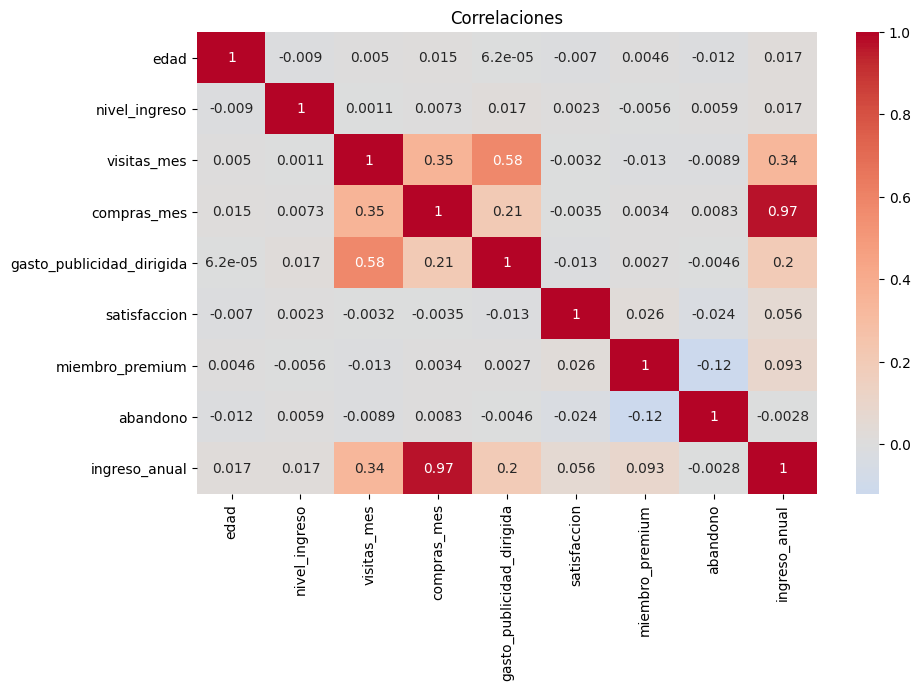

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones

corr=df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlaciones')
plt.show()


✍️ **Comentario**:

Observaciones generales (Heatmap) :

- El gasto_publicidad_dirigida tiene una relación positiva moderada con visitas_mes
- Abandono y miembro_premium muestran una ligera relación negativa


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación muy alta con la variable de compra_mes, indicando una posible colinealidad


### Scatterplot para pares clave

<AxesSubplot:xlabel='visitas_mes', ylabel='ingreso_anual'>

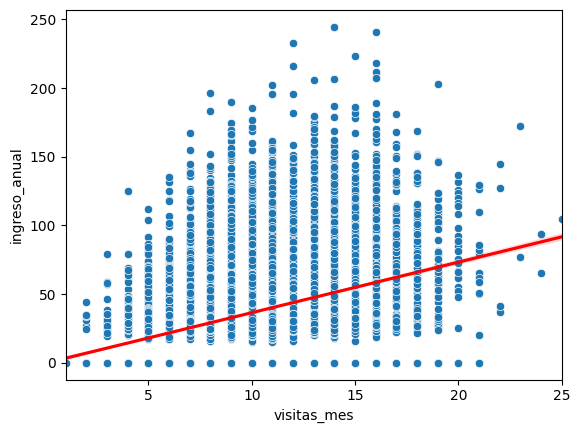

In [ ]:
sns.scatterplot(data=df, x='visitas_mes', y= 'ingreso_anual')
sns.regplot(data=df, x='visitas_mes', y= 'ingreso_anual', scatter=False , color= 'red')

<AxesSubplot:xlabel='compras_mes', ylabel='ingreso_anual'>

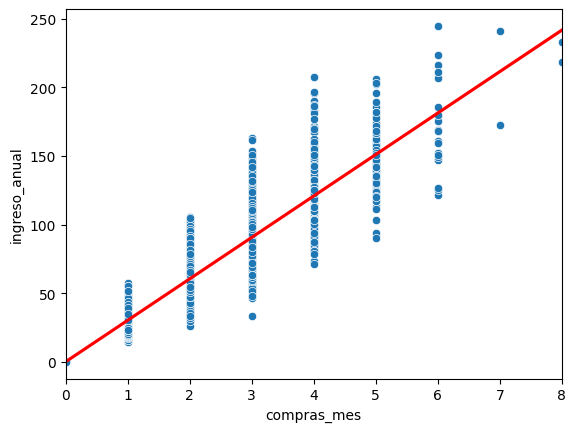

In [ ]:
sns.scatterplot(data=df, x='compras_mes', y= 'ingreso_anual')
sns.regplot(data=df, x='compras_mes', y= 'ingreso_anual', scatter=False , color= 'red')


✍️ **Comentario**:

Observaciones iniciales (Scatterplot)

**ingreso_anual vs visitas_mes**
- Presenta una dirección moderada positiva
- dispersión media

**ingreso_anual vs compras_mes**
- Presenta una dirección positiva muy fuerte, podría indicar colinealidad
- Dispersión baja

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes

cols= ['compras_mes','ingreso_anual','visitas_mes',]
pearson = df[cols].corr(method='pearson')
pearson


,compras_mes,ingreso_anual,visitas_mes
compras_mes,1.000000,0.967149,0.353844
ingreso_anual,0.967149,1.000000,0.337147
visitas_mes,0.353844,0.337147,1.000000


In [ ]:
# Calcular correlación entre variables relevantes
spearman = df[cols].corr(method='spearman')
spearman

,compras_mes,ingreso_anual,visitas_mes
compras_mes,1.000000,0.967482,0.332943
ingreso_anual,0.967482,1.000000,0.320954
visitas_mes,0.332943,0.320954,1.000000


✍️ **Comentario**:

Observaciones de correlación

**ingreso_anual vs compras_mes**
- tanto el coeficiente de Pearson como Spearman marcan valores similares, por lo que la relación es lineal
- Es posible que el alto valor de correlación se deba a colinealidad

**ingreso_ vs visitas_mes**
- tanto el coeficiente de Pearson como Spearman marcan valores similares, por lo que la relación es lineal
  

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes

corrabandono = pointbiserialr(df['abandono'], df['ingreso_anual'])
corrpremium = pointbiserialr(df['miembro_premium'],df['ingreso_anual'])
print('Relación abandono/ingreso_anual:',corrabandono)
print('Relación miembro_premium/ingreso_anual:',corrpremium)


Relación abandono/ingreso_anual: SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)
Relación miembro_premium/ingreso_anual: SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)


✍️ **Comentario**:

Observaciones Punto-biserial

**abandono vs ingreso_anual**
- Relación negativa muy débil
- Al aumentar el abandono, el ingreso anual baja por la perdida de clientes

**ingreso_anual vs miembro_premium**
- Relación positiva débil
- Los miembros premium contribuyen ligeramente mas al ingreso anual de la empresa

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2,p,dof,expected = chi2_contingency(tabla)
    n = tabla.sum().sum()
    v= np.sqrt(chi2/(n*(min(tabla.shape)-1)))
    return v

In [ ]:
# Aplicar V de Cramér en variables relevantes
print('Abandono / Miembro Premium:',cramer_v(df, 'abandono', 'miembro_premium'))
print('Tipo de dispositivo / Region:',cramer_v(df, 'tipo_dispositivo', 'region'))

Abandono / Miembro Premium: 0.12021874609740511
Tipo de dispositivo / Region: 0.012378338407739397


✍️ **Comentario**:

Observaciones V de Cramér
Hay una relación positiva pero débil entre abandono
tipo de dispositivo y región muestran una relación positiva, pero débil


## Sección 5 - Interpretación de resultados para el negocio

✍️ **Hallazgos**:  

### Hallazgo 1 —
visitas_mes-ingreso_anual
**Evidencia visual: Scatter map y Heat map**   
**Evidencia numérica:** Pearson = 0.33

**Interpretación**  
Los usuarios con un mayor número de visitas, tienden a comprar mas, pero esta relación es moderada

**No podemos afirmar**  
Que aumentar las visitas aumente las compras

**Implicación de negocio**  
Explorar estrategias para aumentar engagement previo a la compra y validarlas mediante experimentos controlados.


### Hallazgo 2 —
Usuario_premium-ingreso_anual
**Evidencia visual:**   
**Evidencia numérica: Punto biserial = 0.093**

**Interpretación**  
Los usuarios premium contribuyen ligeramente mas al ingreso anual que los usuarios normales, pero esta relación es muy débil

**No podemos afirmar**  
que los usuarios premium forman gran parte del ingreso anual

**Implicación de negocio**  
Segmentar los usuarios premium por diferentes categorías para encontrar potenciales clientes de alto valor, y dirigirles campañas personalizadas


<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. El primer hallazgo debe centrarse en `compras_mes` vs `ingreso_anual`, con Pearson y Spearman ≈ 0.967. El hallazgo actual de visitas e ingreso corresponde al segundo hallazgo, pero su interpretación cambia de ingreso a compras; debe indicar que los usuarios con más visitas tienden a generar más ingresos, aunque la asociación es moderada.

</div>

## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### **Limitaciones**
- Correlación ≠ causalidad
- Posibles efectos de segmentación no explorados
- Variables no observadas

### **Próximos pasos**

Probar segmentación adicional
- segmentación por dispositivo y región
- implementación de experimentos A/B
- Análisis de cohortes

